# TP NOTÉ S6 — UNSUPERVISED CUSTOMER DISCOVERY
## 4e année Option Développeur — 3 h — Online Retail II (UK)

**Rendu :** un notebook Jupyter entièrement exécuté. Toute décision doit être justifiée par vos propres résultats.

**Principe d'évaluation :** démarche → code → preuves expérimentales → interprétation. Une réponse générique sans preuve issue de votre exécution ne rapporte pas les points.

## Mission — 5 pts

Vous recevez des transactions d'un retailer britannique. **Aucune cible de segmentation ne vous est fournie.**

Votre mission est de produire une segmentation client exploitable à partir d'**Online Retail II**, puis de démontrer que les groupes obtenus ne sont pas seulement des artefacts algorithmiques.

In [1]:
from pathlib import Path
import inspect
import os
import platform
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score, normalized_mutual_info_score
)

warnings.filterwarnings("ignore", category=FutureWarning)
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "2")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

WINDOWS_DATA_DIR = Path(r"C:\Users\brani\Documents\trining\data")
candidate_dirs = [
    WINDOWS_DATA_DIR,
    Path.cwd() / "data",
    Path.cwd().parent / "data",
    Path.cwd(),
]
DATA_DIR = next((p for p in candidate_dirs if (p / "online_retail_II.xlsx").exists()), None)
if DATA_DIR is None:
    checked = "\n - ".join(str(p) for p in candidate_dirs)
    raise FileNotFoundError(
        "online_retail_II.xlsx est introuvable. Décompressez le ZIP dans le dossier data.\n"
        f"Dossiers vérifiés :\n - {checked}"
    )

DATA_PATH = DATA_DIR / "online_retail_II.xlsx"
t0 = time.perf_counter()
raw_sheets = pd.read_excel(DATA_PATH, sheet_name=None)
load_seconds = time.perf_counter() - t0

transactions = pd.concat(
    [frame.assign(SourceSheet=sheet) for sheet, frame in raw_sheets.items()],
    ignore_index=True,
)
transactions["InvoiceDate"] = pd.to_datetime(transactions["InvoiceDate"], errors="coerce")
RAW_TRANSACTION_COLUMNS = [c for c in transactions.columns if c != "SourceSheet"]

audit_global = pd.DataFrame({
    "indicateur": [
        "Feuilles", "Transactions", "Colonnes", "Date minimale", "Date maximale",
        "Clients manquants", "Descriptions manquantes", "Doublons exacts",
        "Factures annulées (préfixe C)", "Quantités <= 0", "Prix <= 0", "Pays"
    ],
    "valeur": [
        ", ".join(raw_sheets.keys()), f"{len(transactions):,}", transactions.shape[1],
        str(transactions["InvoiceDate"].min()), str(transactions["InvoiceDate"].max()),
        int(transactions["Customer ID"].isna().sum()), int(transactions["Description"].isna().sum()),
        int(transactions.duplicated(subset=RAW_TRANSACTION_COLUMNS).sum()),
        int(transactions["Invoice"].astype(str).str.startswith("C", na=False).sum()),
        int((transactions["Quantity"] <= 0).sum()), int((transactions["Price"] <= 0).sum()),
        int(transactions["Country"].nunique()),
    ],
})

print(f"Python : {platform.python_version()} | random_state = {RANDOM_STATE}")
print(f"Fichier : {DATA_PATH.resolve()}")
print(f"Chargement des deux feuilles : {load_seconds:.1f} s")
display(audit_global)
display(transactions.head())

sheet_summary = (
    transactions.groupby("SourceSheet")
    .agg(
        lignes=("Invoice", "size"),
        factures=("Invoice", "nunique"),
        clients_identifiés=("Customer ID", "nunique"),
        date_min=("InvoiceDate", "min"),
        date_max=("InvoiceDate", "max"),
    )
)
display(sheet_summary)

Python : 3.12.14 | random_state = 42
Fichier : /workspace/scratch/87e58d605725/TP_S6_Unsupervised/data/online_retail_II.xlsx
Chargement des deux feuilles : 76.3 s


,indicateur,valeur
0,Feuilles,"Year 2009-2010, Year 2010-2011"
1,Transactions,"1,067,371"
2,Colonnes,9
3,Date minimale,2009-12-01 07:45:00
4,Date maximale,2011-12-09 12:50:00
5,Clients manquants,243007
6,Descriptions manquantes,4382
7,Doublons exacts,34335
8,Factures annulées (préfixe C),19494
9,Quantités <= 0,22950


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SourceSheet
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.950,"13,085.000",United Kingdom,Year 2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,"13,085.000",United Kingdom,Year 2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,"13,085.000",United Kingdom,Year 2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.100,"13,085.000",United Kingdom,Year 2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.250,"13,085.000",United Kingdom,Year 2009-2010


,lignes,factures,clients_identifiés,date_min,date_max
SourceSheet,,,,,
Year 2009-2010,525461,28816,4383,2009-12-01 07:45:00,2010-12-09 20:01:00
Year 2010-2011,541910,25900,4372,2010-12-01 08:26:00,2011-12-09 12:50:00


## De la transaction au client — 20 pts

Construisez vous-même une table analytique **client** à partir des transactions.

Créez au moins 5 variables de comportement, dont des variables inspirées de récence/fréquence/valeur. Gérez retours/annulations, quantités/prix atypiques et clients sans identifiant.

Chaque feature doit avoir une définition métier et une justification.

Seuils descriptifs P99,9 : Quantity=576.0, Price=49.95.
Les lignes extrêmes restent dans les agrégats métier ; elles seront winsorisées seulement pour le clustering et réexaminées comme anomalies.
Table client : 5,878 clients avec au moins un achat valide ; date de référence = 2011-12-10.


,étape / règle,lignes,% du brut
0,Transactions initiales,1067371,100.000
1,Doublons exacts retirés,34335,3.217
2,Lignes sans Customer ID exclues de la segmentation,235151,22.031
3,Retours/annulations isolés pour créer des features,18390,1.723
4,"Achats valides (Quantity > 0, Price > 0, non annulés)",779425,73.023
5,"Lignes atypiques > P99,9 quantité ou prix, conservées et signalées",1513,0.142


,feature,définition métier,justification
0,recency_days,Jours depuis le dernier achat à la date d'observation,Mesure l'inactivité
1,frequency,Nombre de factures d'achat distinctes,Mesure la répétition
2,monetary_net,Montant acheté moins valeur absolue des retours,Mesure la valeur nette
3,avg_basket,Montant brut moyen par facture,Distingue fréquence et taille de panier
4,quantity_total,Nombre total d'unités achetées,Repère volume et grossistes
5,unique_products,Nombre de références distinctes achetées,Mesure la diversité
6,active_days,Jours entre premier et dernier achat (+1),Mesure l'ancienneté de relation
7,orders_per_month,"Factures par mois actif, avec au moins un mois au dénominateur",Normalise la fréquence par durée
8,return_rate_lines,Part des lignes de retour parmi lignes d'achat et de retour,Quantifie le comportement de retour


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
recency_days,"5,878.000",NaN,NaN,NaN,201.867,209.354,1.000,26.000,96.000,380.000,739.000
frequency,"5,878.000",NaN,NaN,NaN,6.289,13.009,1.000,1.000,3.000,7.000,398.000
monetary_net,"5,878.000",NaN,NaN,NaN,"2,781.735","13,741.219","-10,953.500",329.685,838.855,"2,165.267","570,380.610"
avg_basket,"5,878.000",NaN,NaN,NaN,385.181,"1,214.286",2.950,176.683,279.243,414.902,"84,236.250"
quantity_total,"5,878.000",NaN,NaN,NaN,"1,788.695","8,876.297",1.000,187.000,480.000,"1,350.000","367,193.000"
unique_products,"5,878.000",NaN,NaN,NaN,81.989,116.485,1.000,19.000,45.000,103.000,"2,550.000"
active_days,"5,878.000",NaN,NaN,NaN,274.022,258.808,1.000,1.000,221.500,512.000,739.000
orders_per_month,"5,878.000",NaN,NaN,NaN,0.875,0.773,0.085,0.398,0.827,1.000,16.416
return_rate_lines,"5,878.000",NaN,NaN,NaN,0.027,0.068,0.000,0.000,0.000,0.025,0.750
main_country,5878,41,United Kingdom,5350,NaN,NaN,NaN,NaN,NaN,NaN,NaN


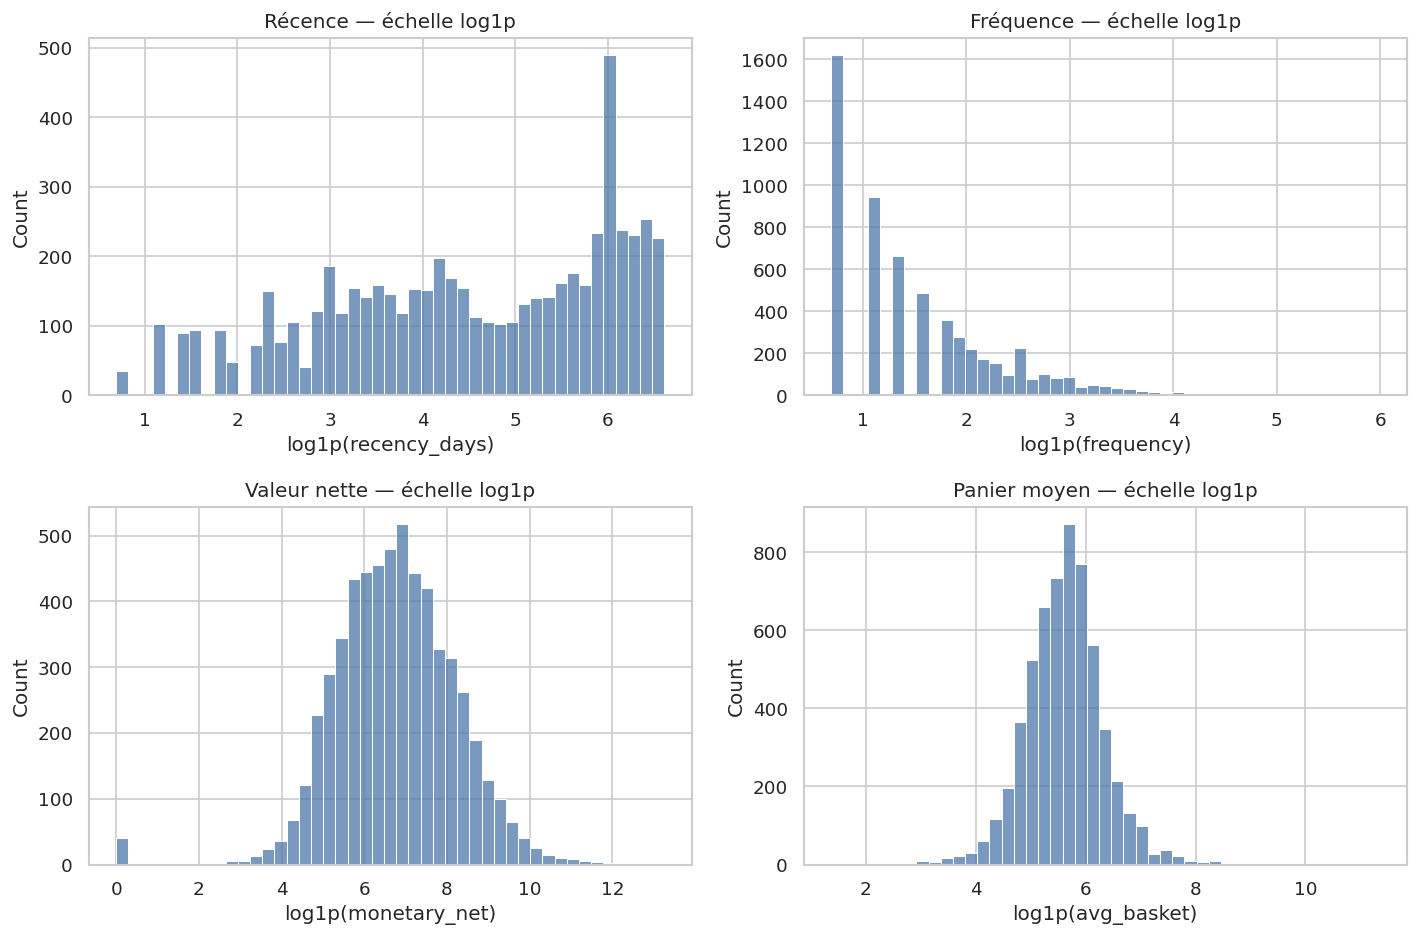

In [2]:
# 1) Traçabilité du nettoyage : aucune suppression silencieuse.
transactions = transactions.copy()
transactions["Invoice_str"] = transactions["Invoice"].astype(str).str.strip()
transactions["is_cancelled"] = transactions["Invoice_str"].str.startswith("C", na=False)

n_initial = len(transactions)
n_duplicates = int(transactions.duplicated(subset=RAW_TRANSACTION_COLUMNS).sum())
dedup = transactions.drop_duplicates(subset=RAW_TRANSACTION_COLUMNS).copy()
n_missing_customer = int(dedup["Customer ID"].isna().sum())

identified = dedup[dedup["Customer ID"].notna()].copy()
identified["CustomerID"] = identified["Customer ID"].astype("int64")

returns = identified[
    identified["is_cancelled"] | (identified["Quantity"] < 0)
].copy()
returns["return_value_abs"] = (returns["Quantity"] * returns["Price"]).abs()

purchases = identified[
    (~identified["is_cancelled"])
    & (identified["Quantity"] > 0)
    & (identified["Price"] > 0)
    & identified["InvoiceDate"].notna()
].copy()
purchases["line_amount"] = purchases["Quantity"] * purchases["Price"]

quantity_p999 = float(purchases["Quantity"].quantile(0.999))
price_p999 = float(purchases["Price"].quantile(0.999))
n_atypical_lines = int(((purchases["Quantity"] > quantity_p999) | (purchases["Price"] > price_p999)).sum())

cleaning_audit = pd.DataFrame({
    "étape / règle": [
        "Transactions initiales",
        "Doublons exacts retirés",
        "Lignes sans Customer ID exclues de la segmentation",
        "Retours/annulations isolés pour créer des features",
        "Achats valides (Quantity > 0, Price > 0, non annulés)",
        "Lignes atypiques > P99,9 quantité ou prix, conservées et signalées",
    ],
    "lignes": [n_initial, n_duplicates, n_missing_customer, len(returns), len(purchases), n_atypical_lines],
    "% du brut": np.array([n_initial, n_duplicates, n_missing_customer, len(returns), len(purchases), n_atypical_lines]) / n_initial * 100,
})
display(cleaning_audit.round(3))
print(f"Seuils descriptifs P99,9 : Quantity={quantity_p999:.1f}, Price={price_p999:.2f}.")
print("Les lignes extrêmes restent dans les agrégats métier ; elles seront winsorisées seulement pour le clustering et réexaminées comme anomalies.")

# 2) Construction d'une table analytique au niveau client.
snapshot_date = purchases["InvoiceDate"].max().normalize() + pd.Timedelta(days=1)

customer = purchases.groupby("CustomerID").agg(
    last_purchase=("InvoiceDate", "max"),
    first_purchase=("InvoiceDate", "min"),
    frequency=("Invoice_str", "nunique"),
    monetary_gross=("line_amount", "sum"),
    quantity_total=("Quantity", "sum"),
    purchase_lines=("Invoice_str", "size"),
    unique_products=("StockCode", "nunique"),
).sort_index()

return_features = returns.groupby("CustomerID").agg(
    return_lines=("Invoice_str", "size"),
    return_invoices=("Invoice_str", "nunique"),
    return_value=("return_value_abs", "sum"),
)
customer = customer.join(return_features, how="left").fillna({
    "return_lines": 0, "return_invoices": 0, "return_value": 0
})

main_country = purchases.groupby("CustomerID")["Country"].agg(
    lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]
)
customer = customer.join(main_country.rename("main_country"))

customer["recency_days"] = (snapshot_date - customer["last_purchase"].dt.normalize()).dt.days
customer["active_days"] = (customer["last_purchase"] - customer["first_purchase"]).dt.days + 1
customer["monetary_net"] = customer["monetary_gross"] - customer["return_value"]
customer["avg_basket"] = customer["monetary_gross"] / customer["frequency"].clip(lower=1)
customer["orders_per_month"] = customer["frequency"] / np.maximum(customer["active_days"] / 30.44, 1)
customer["return_rate_lines"] = customer["return_lines"] / (customer["purchase_lines"] + customer["return_lines"]).clip(lower=1)

FEATURES = [
    "recency_days", "frequency", "monetary_net", "avg_basket",
    "quantity_total", "unique_products", "active_days",
    "orders_per_month", "return_rate_lines"
]

feature_dictionary = pd.DataFrame({
    "feature": FEATURES,
    "définition métier": [
        "Jours depuis le dernier achat à la date d'observation",
        "Nombre de factures d'achat distinctes",
        "Montant acheté moins valeur absolue des retours",
        "Montant brut moyen par facture",
        "Nombre total d'unités achetées",
        "Nombre de références distinctes achetées",
        "Jours entre premier et dernier achat (+1)",
        "Factures par mois actif, avec au moins un mois au dénominateur",
        "Part des lignes de retour parmi lignes d'achat et de retour",
    ],
    "justification": [
        "Mesure l'inactivité", "Mesure la répétition", "Mesure la valeur nette",
        "Distingue fréquence et taille de panier", "Repère volume et grossistes",
        "Mesure la diversité", "Mesure l'ancienneté de relation",
        "Normalise la fréquence par durée", "Quantifie le comportement de retour",
    ],
})
display(feature_dictionary)
print(f"Table client : {len(customer):,} clients avec au moins un achat valide ; date de référence = {snapshot_date.date()}.")
display(customer[FEATURES + ["main_country"]].describe(include="all").T)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col, title in zip(
    axes.ravel(),
    ["recency_days", "frequency", "monetary_net", "avg_basket"],
    ["Récence", "Fréquence", "Valeur nette", "Panier moyen"],
):
    sns.histplot(np.log1p(customer[col].clip(lower=0)), bins=45, ax=ax, color="#4C78A8")
    ax.set_title(f"{title} — échelle log1p")
    ax.set_xlabel(f"log1p({col})")
plt.tight_layout()

# Libération des transactions détaillées : les analyses suivantes travaillent au niveau client.
del raw_sheets, transactions, dedup, identified

## K-Means — 20 pts

Préparez les données puis testez plusieurs K. Utilisez au moins deux arguments pour sélectionner K (ex. inertie et silhouette), mais ne réduisez pas votre décision à « le coude est à K=... ».

Profilez chaque cluster sur les variables originales.

Bornes de winsorisation utilisées seulement pour l'apprentissage des clusters :
Moyennes standardisées proches de 0 : [-0. -0. -0. -0.  0. -0.  0.  0. -0.]
Écarts-types standardisés proches de 1 : [1. 1. 1. 1. 1. 1. 1. 1. 1.]
K retenu = 3 par règle multi-critères ; le plus petit segment représente 24.87% des clients.


,P0.5,P99.5
recency_days,1.000,734.000
frequency,1.000,68.230
monetary_net,0.000,"49,987.062"
avg_basket,22.847,"2,900.241"
quantity_total,2.000,"41,776.245"
unique_products,1.000,599.460
active_days,1.000,736.000
orders_per_month,0.115,4.399
return_rate_lines,0.000,0.500


,K,inertie,silhouette,Calinski-Harabasz,Davies-Bouldin,plus_petit_cluster_%
0,2,"34,248.252",0.329,"3,200.441",1.209,43.569
1,3,"28,213.054",0.267,"2,570.581",1.327,24.872
2,4,"24,659.339",0.284,"2,242.523",1.220,2.671
3,5,"21,957.490",0.253,"2,069.195",1.264,2.518
4,6,"20,035.976",0.215,"1,926.441",1.359,2.535
5,7,"18,652.547",0.221,"1,796.703",1.324,2.229
6,8,"17,608.032",0.203,"1,680.861",1.403,2.127
7,9,"16,596.510",0.206,"1,604.836",1.359,0.919
8,10,"15,772.411",0.207,"1,534.863",1.339,0.970


,segment,clients,part_%,recency_days,frequency,monetary_net,avg_basket,quantity_total,unique_products,active_days,orders_per_month,return_rate_lines
kmeans_cluster,,,,,,,,,,,,
0,Inactifs,2114,35.965,382.000,1.000,255.065,214.800,146.000,17.000,1.000,1.000,0.000
1,Forte valeur,1462,24.872,19.000,11.000,"4,303.290",388.180,"2,526.500",158.500,596.500,0.754,0.013
2,Fidèles,2302,39.163,97.000,4.000,962.410,261.414,538.000,50.000,358.500,0.362,0.000


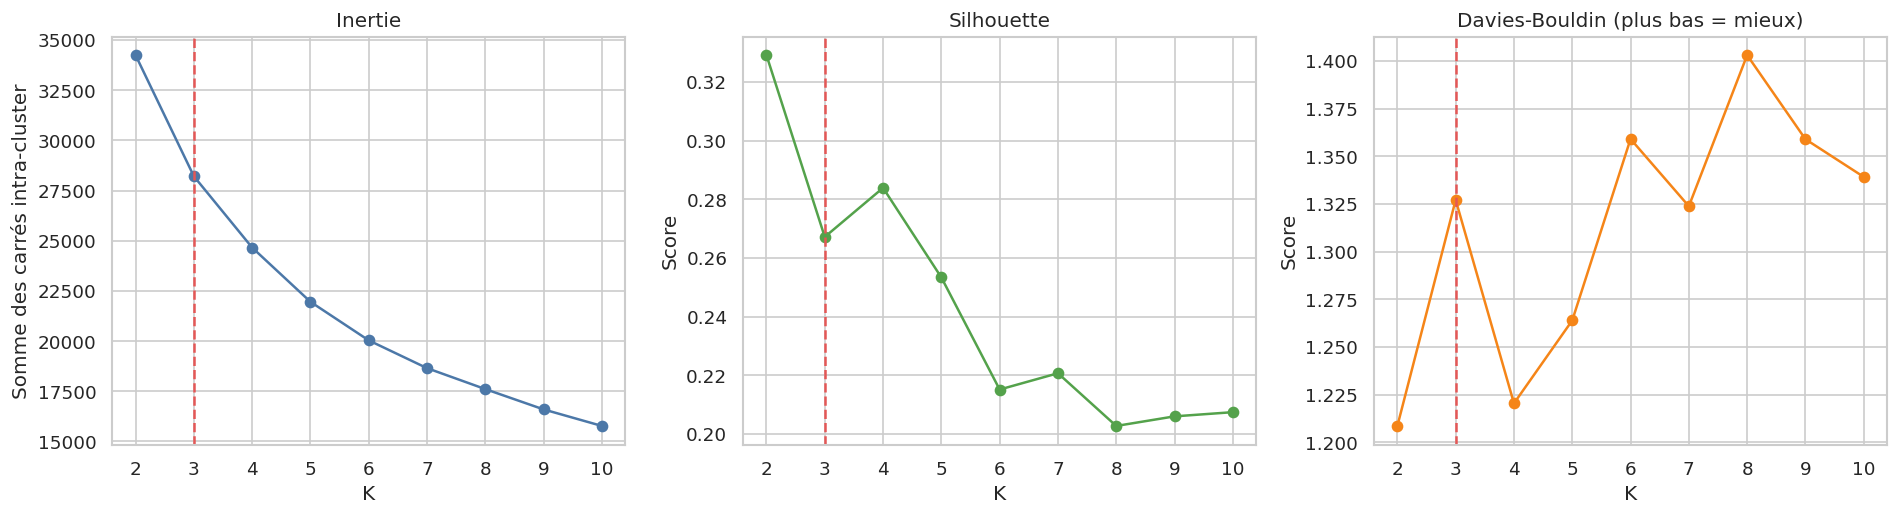

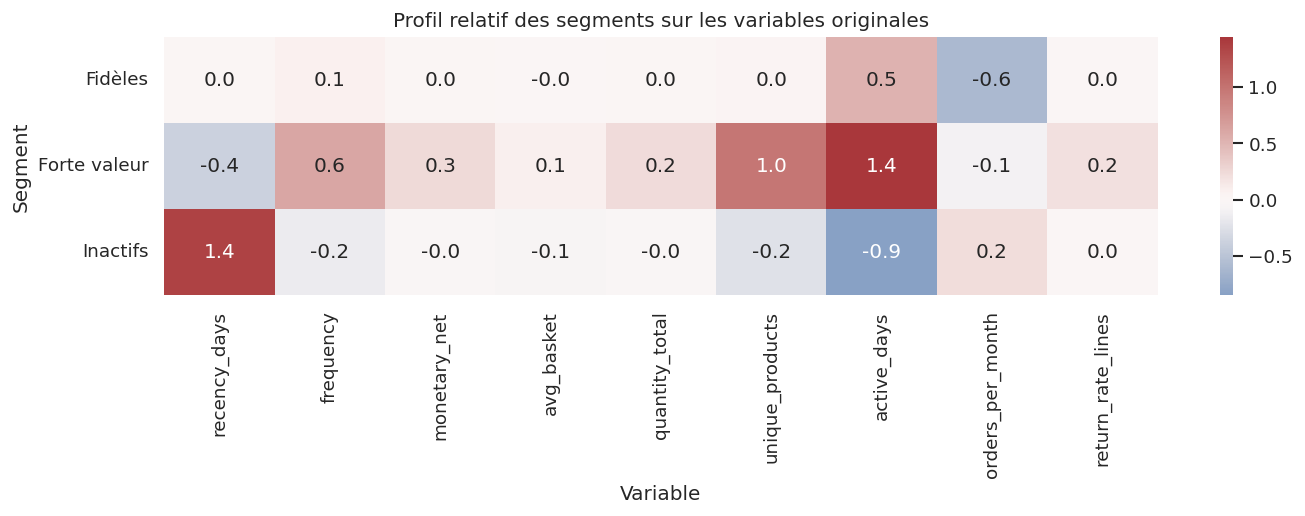

In [3]:
# Préparation robuste : winsorisation pour le clustering uniquement, log1p puis standardisation.
model_frame = customer[FEATURES].copy()
model_frame["monetary_net"] = model_frame["monetary_net"].clip(lower=0)

winsor_bounds = pd.DataFrame({
    "P0.5": model_frame.quantile(0.005),
    "P99.5": model_frame.quantile(0.995),
})
model_winsor = model_frame.copy()
for col in FEATURES:
    model_winsor[col] = model_winsor[col].clip(
        lower=winsor_bounds.loc[col, "P0.5"],
        upper=winsor_bounds.loc[col, "P99.5"],
    )

X_log = np.log1p(model_winsor)
scaler = StandardScaler()
X_model = scaler.fit_transform(X_log)

print("Bornes de winsorisation utilisées seulement pour l'apprentissage des clusters :")
display(winsor_bounds.round(3))
print("Moyennes standardisées proches de 0 :", np.round(X_model.mean(axis=0), 6))
print("Écarts-types standardisés proches de 1 :", np.round(X_model.std(axis=0), 6))

# Plusieurs K, avec quatre diagnostics complémentaires.
k_rows = []
k_models = {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_model)
    counts = np.bincount(labels)
    k_rows.append({
        "K": k,
        "inertie": km.inertia_,
        "silhouette": silhouette_score(
            X_model, labels, sample_size=min(3000, len(X_model)), random_state=RANDOM_STATE
        ),
        "Calinski-Harabasz": calinski_harabasz_score(X_model, labels),
        "Davies-Bouldin": davies_bouldin_score(X_model, labels),
        "plus_petit_cluster_%": 100 * counts.min() / len(labels),
    })
    k_models[k] = km

k_evaluation = pd.DataFrame(k_rows)
display(k_evaluation.round(4))

# Règle explicite : parmi K=3..6 avec aucun segment <3%, minimiser la somme des rangs
# silhouette (max), Calinski-Harabasz (max) et Davies-Bouldin (min).
candidates = k_evaluation.loc[
    k_evaluation["K"].between(3, 6)
    & (k_evaluation["plus_petit_cluster_%"] >= 3)
].copy()
if candidates.empty:
    candidates = k_evaluation.loc[k_evaluation["K"].between(3, 6)].copy()
candidates["rang_qualité"] = (
    candidates["silhouette"].rank(ascending=False)
    + candidates["Calinski-Harabasz"].rank(ascending=False)
    + candidates["Davies-Bouldin"].rank(ascending=True)
)
SELECTED_K = int(candidates.sort_values(["rang_qualité", "silhouette"], ascending=[True, False]).iloc[0]["K"])

final_kmeans = k_models[SELECTED_K]
kmeans_labels = final_kmeans.labels_
customer["kmeans_cluster"] = kmeans_labels

cluster_profile = customer.groupby("kmeans_cluster")[FEATURES].median()
cluster_profile.insert(0, "clients", customer.groupby("kmeans_cluster").size())
cluster_profile.insert(1, "part_%", 100 * cluster_profile["clients"] / len(customer))

# Noms de travail déterminés à partir des médianes observées, sans changer les labels numériques.
remaining = set(cluster_profile.index)
segment_names = {}
high_value = cluster_profile["monetary_net"].idxmax()
segment_names[high_value] = "Forte valeur"
remaining.remove(high_value)
if remaining:
    dormant = cluster_profile.loc[list(remaining), "recency_days"].idxmax()
    segment_names[dormant] = "Inactifs"
    remaining.remove(dormant)
if remaining:
    loyal = cluster_profile.loc[list(remaining), "frequency"].idxmax()
    segment_names[loyal] = "Fidèles"
    remaining.remove(loyal)
for number, cluster_id in enumerate(sorted(remaining), start=1):
    segment_names[cluster_id] = f"Occasionnels {number}"

customer["segment"] = customer["kmeans_cluster"].map(segment_names)
profile_named = cluster_profile.copy()
profile_named.insert(0, "segment", profile_named.index.map(segment_names))

print(f"K retenu = {SELECTED_K} par règle multi-critères ; le plus petit segment représente {cluster_profile['part_%'].min():.2f}% des clients.")
display(profile_named.round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(k_evaluation["K"], k_evaluation["inertie"], marker="o", color="#4C78A8")
axes[0].axvline(SELECTED_K, color="#E45756", linestyle="--")
axes[0].set(title="Inertie", xlabel="K", ylabel="Somme des carrés intra-cluster")
axes[1].plot(k_evaluation["K"], k_evaluation["silhouette"], marker="o", color="#54A24B")
axes[1].axvline(SELECTED_K, color="#E45756", linestyle="--")
axes[1].set(title="Silhouette", xlabel="K", ylabel="Score")
axes[2].plot(k_evaluation["K"], k_evaluation["Davies-Bouldin"], marker="o", color="#F58518")
axes[2].axvline(SELECTED_K, color="#E45756", linestyle="--")
axes[2].set(title="Davies-Bouldin (plus bas = mieux)", xlabel="K", ylabel="Score")
plt.tight_layout()

profile_for_heatmap = customer.groupby("segment")[FEATURES].median()
standardized_profile = (profile_for_heatmap - customer[FEATURES].median()) / customer[FEATURES].std(ddof=0)
plt.figure(figsize=(12, max(4.5, SELECTED_K * 1.1)))
heatmap_ax = sns.heatmap(standardized_profile, cmap="vlag", center=0, annot=True, fmt=".1f")
heatmap_ax.set_yticklabels(heatmap_ax.get_yticklabels(), rotation=0, ha="right")
plt.title("Profil relatif des segments sur les variables originales")
plt.xlabel("Variable")
plt.ylabel("Segment")
plt.tight_layout()

## CAH & DBSCAN — 20 pts

Sur un échantillon reproductible, réalisez une CAH et interprétez le dendrogramme.

Appliquez ensuite DBSCAN. Justifiez la recherche de `eps` et `min_samples`. Quantifiez les points bruités.

Comparez structurellement les résultats des trois méthodes.

CAH calculée en 0.02 s. Accord K-Means/CAH : ARI=0.556, NMI=0.556.
DBSCAN retenu : eps=1.0479, min_samples=15, 2 groupes, bruit=13.15%.
Sur l'échantillon hors bruit : ARI K-Means/DBSCAN=0.415, ARI CAH/DBSCAN=0.368.
Interprétation : un ARI faible indique que les méthodes n'imposent pas la même structure ; DBSCAN cherche des zones denses et peut isoler du bruit, contrairement à K-Means/CAH.


,eps,min_samples,clusters_hors_bruit,bruit_%,silhouette_hors_bruit
0,1.048,15,2,13.151,0.363
1,1.137,15,2,9.884,0.340
2,1.259,15,2,7.026,0.329
3,1.370,15,2,5.274,0.317
4,1.446,15,2,4.423,0.322
5,1.549,15,1,3.454,NaN
6,1.813,15,1,2.280,NaN
7,2.458,15,2,0.680,0.614


,méthode,n analysé,groupes hors bruit,bruit_%,silhouette
0,K-Means (tous),5878,3,0.000,0.267
1,CAH Ward (échantillon),1200,3,0.000,0.195
2,DBSCAN (tous),5878,2,13.151,0.363


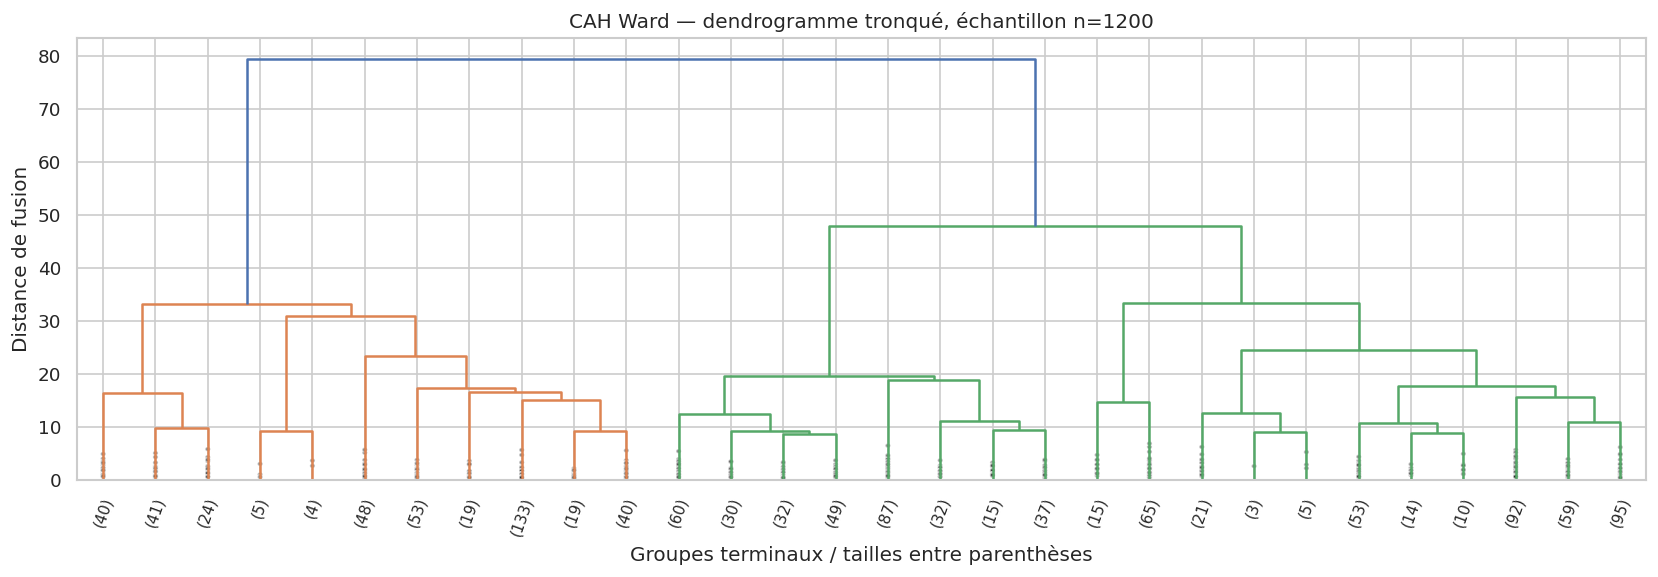

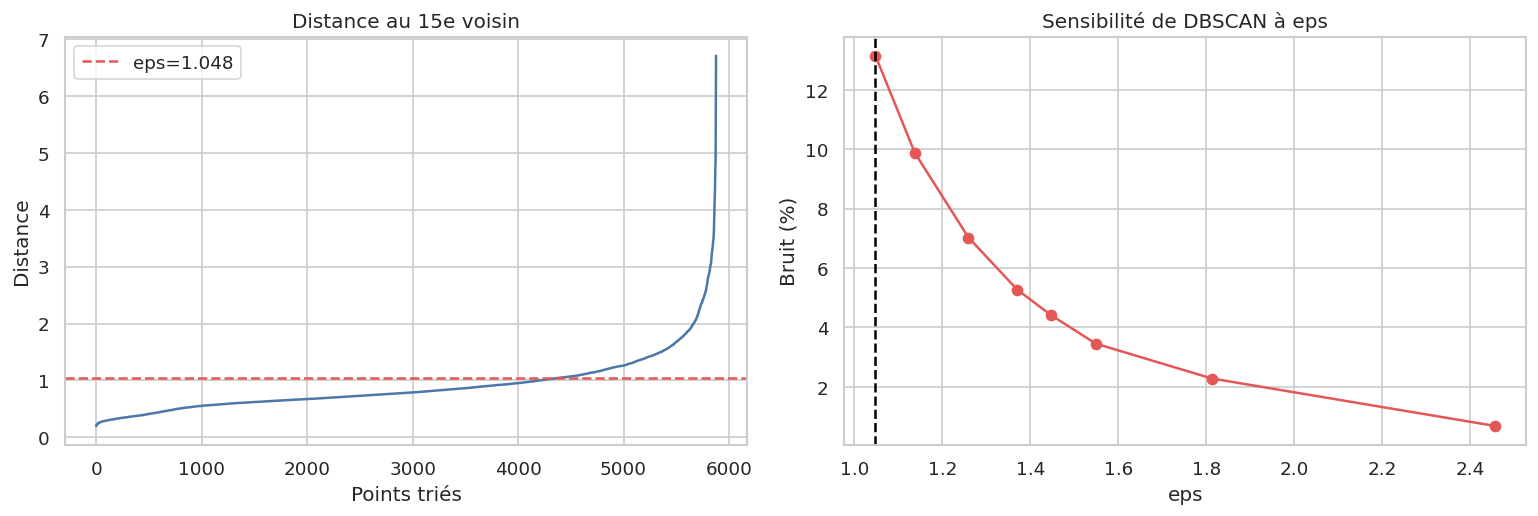

In [4]:
# CAH sur un échantillon reproductible pour limiter la complexité quadratique.
rng = np.random.default_rng(RANDOM_STATE)
sample_size = min(1200, len(X_model))
cah_indices = np.sort(rng.choice(len(X_model), size=sample_size, replace=False))
X_cah = X_model[cah_indices]

t0 = time.perf_counter()
linkage_matrix = linkage(X_cah, method="ward")
cah_seconds = time.perf_counter() - t0

plt.figure(figsize=(14, 5))
dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=70,
    leaf_font_size=9,
    show_contracted=True,
)
plt.title(f"CAH Ward — dendrogramme tronqué, échantillon n={sample_size}")
plt.xlabel("Groupes terminaux / tailles entre parenthèses")
plt.ylabel("Distance de fusion")
plt.tight_layout()

cah = AgglomerativeClustering(n_clusters=SELECTED_K, linkage="ward")
cah_labels = cah.fit_predict(X_cah)
cah_silhouette = silhouette_score(X_cah, cah_labels)

# DBSCAN : min_samples fixé à 2×dimension environ, eps étudié par quantiles
# de la distance au 15e voisin.
MIN_SAMPLES = 15
neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_model)
distances, _ = neighbors.kneighbors(X_model)
k_distance = np.sort(distances[:, -1])
eps_quantiles = np.array([0.75, 0.80, 0.85, 0.88, 0.90, 0.92, 0.95, 0.98])
eps_values = np.unique(np.quantile(k_distance, eps_quantiles))

dbscan_rows = []
dbscan_labels_by_eps = {}
for eps in eps_values:
    labels = DBSCAN(eps=float(eps), min_samples=MIN_SAMPLES, n_jobs=-1).fit_predict(X_model)
    non_noise = labels != -1
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = 100 * (~non_noise).mean()
    sil = np.nan
    if n_clusters >= 2 and non_noise.sum() > n_clusters:
        sil = silhouette_score(
            X_model[non_noise], labels[non_noise],
            sample_size=min(3000, int(non_noise.sum())), random_state=RANDOM_STATE
        )
    dbscan_rows.append({
        "eps": float(eps), "min_samples": MIN_SAMPLES,
        "clusters_hors_bruit": n_clusters, "bruit_%": noise_pct,
        "silhouette_hors_bruit": sil,
    })
    dbscan_labels_by_eps[float(eps)] = labels

dbscan_search = pd.DataFrame(dbscan_rows)
display(dbscan_search.round(4))

valid_dbscan = dbscan_search.loc[
    dbscan_search["clusters_hors_bruit"].between(2, 10)
    & dbscan_search["bruit_%"].between(1, 35)
].dropna(subset=["silhouette_hors_bruit"])
if valid_dbscan.empty:
    valid_dbscan = dbscan_search.loc[
        dbscan_search["clusters_hors_bruit"] >= 2
    ].dropna(subset=["silhouette_hors_bruit"])
if valid_dbscan.empty:
    chosen_dbscan_row = dbscan_search.iloc[(dbscan_search["bruit_%"] - 10).abs().argsort().iloc[0]]
else:
    chosen_dbscan_row = valid_dbscan.sort_values(
        ["silhouette_hors_bruit", "bruit_%"], ascending=[False, True]
    ).iloc[0]

BEST_EPS = float(chosen_dbscan_row["eps"])
dbscan_labels = dbscan_labels_by_eps[BEST_EPS]
customer["dbscan_label"] = dbscan_labels
dbscan_non_noise = dbscan_labels != -1
dbscan_clusters = int(chosen_dbscan_row["clusters_hors_bruit"])
dbscan_noise_pct = float(chosen_dbscan_row["bruit_%"])

common = dbscan_labels[cah_indices] != -1
comparison = pd.DataFrame({
    "méthode": ["K-Means (tous)", "CAH Ward (échantillon)", "DBSCAN (tous)"],
    "n analysé": [len(X_model), sample_size, len(X_model)],
    "groupes hors bruit": [SELECTED_K, SELECTED_K, dbscan_clusters],
    "bruit_%": [0.0, 0.0, dbscan_noise_pct],
    "silhouette": [
        float(k_evaluation.loc[k_evaluation["K"] == SELECTED_K, "silhouette"].iloc[0]),
        cah_silhouette,
        float(chosen_dbscan_row["silhouette_hors_bruit"]) if pd.notna(chosen_dbscan_row["silhouette_hors_bruit"]) else np.nan,
    ],
})
display(comparison.round(4))

ari_kmeans_cah = adjusted_rand_score(kmeans_labels[cah_indices], cah_labels)
nmi_kmeans_cah = normalized_mutual_info_score(kmeans_labels[cah_indices], cah_labels)
if common.sum() > 1:
    ari_kmeans_dbscan = adjusted_rand_score(kmeans_labels[cah_indices][common], dbscan_labels[cah_indices][common])
    ari_cah_dbscan = adjusted_rand_score(cah_labels[common], dbscan_labels[cah_indices][common])
else:
    ari_kmeans_dbscan = np.nan
    ari_cah_dbscan = np.nan

print(f"CAH calculée en {cah_seconds:.2f} s. Accord K-Means/CAH : ARI={ari_kmeans_cah:.3f}, NMI={nmi_kmeans_cah:.3f}.")
print(f"DBSCAN retenu : eps={BEST_EPS:.4f}, min_samples={MIN_SAMPLES}, {dbscan_clusters} groupes, bruit={dbscan_noise_pct:.2f}%.")
print(f"Sur l'échantillon hors bruit : ARI K-Means/DBSCAN={ari_kmeans_dbscan:.3f}, ARI CAH/DBSCAN={ari_cah_dbscan:.3f}.")
print("Interprétation : un ARI faible indique que les méthodes n'imposent pas la même structure ; DBSCAN cherche des zones denses et peut isoler du bruit, contrairement à K-Means/CAH.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(np.arange(len(k_distance)), k_distance, color="#4C78A8")
axes[0].axhline(BEST_EPS, color="#E45756", linestyle="--", label=f"eps={BEST_EPS:.3f}")
axes[0].set(title=f"Distance au {MIN_SAMPLES}e voisin", xlabel="Points triés", ylabel="Distance")
axes[0].legend()
axes[1].plot(dbscan_search["eps"], dbscan_search["bruit_%"], marker="o", label="Bruit (%)", color="#E45756")
axes[1].set(title="Sensibilité de DBSCAN à eps", xlabel="eps", ylabel="Bruit (%)")
axes[1].axvline(BEST_EPS, color="black", linestyle="--")
plt.tight_layout()

## PCA / t-SNE — 15 pts

Utilisez PCA puis t-SNE pour explorer la structure. Pour PCA, quantifiez la variance expliquée. Pour t-SNE, testez au moins deux configurations.

Expliquez explicitement ce qu'on **ne peut pas conclure** d'une carte t-SNE.

PC1+PC2 expliquent 65.05% de la variance standardisée ; 4 composantes sont nécessaires pour atteindre 80%.
Comparaison : les voisinages locaux visibles changent avec la perplexité ; seules les structures persistantes dans les deux cartes sont relativement robustes.
On ne peut PAS déduire d'une carte t-SNE : le nombre vrai de segments, la distance globale entre îlots, leur densité relative, une causalité, ni la performance future d'une segmentation.


,composante,variance_expliquée_%,variance_cumulée_%
0,1,51.279,51.279
1,2,13.774,65.053
2,3,11.606,76.659
3,4,10.891,87.550
4,5,6.219,93.770
5,6,3.593,97.362
6,7,1.134,98.496
7,8,0.957,99.453
8,9,0.547,100.000


,configuration,échantillon,temps_s
0,t-SNE perplexité 15,2500,15.881
1,t-SNE perplexité 50,2500,24.151


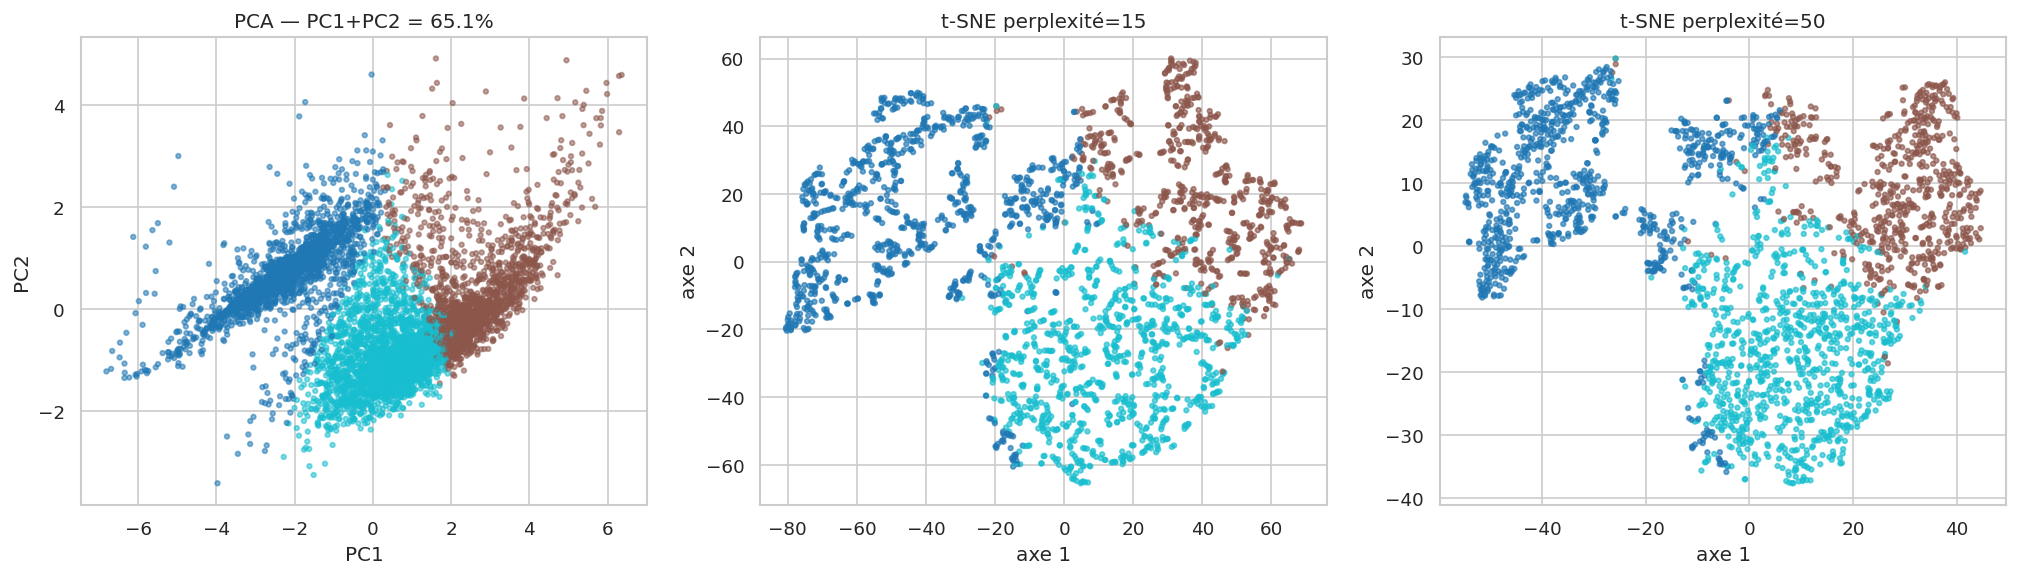

In [5]:
# PCA : analyse de la variance expliquée sur tous les clients.
pca_full = PCA(random_state=RANDOM_STATE).fit(X_model)
pca_coordinates = pca_full.transform(X_model)
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)
pca_table = pd.DataFrame({
    "composante": np.arange(1, len(explained) + 1),
    "variance_expliquée_%": 100 * explained,
    "variance_cumulée_%": 100 * cumulative,
})
display(pca_table.round(3))

n80 = int(np.argmax(cumulative >= 0.80) + 1)
print(f"PC1+PC2 expliquent {100*cumulative[1]:.2f}% de la variance standardisée ; {n80} composantes sont nécessaires pour atteindre 80%.")

# t-SNE sur le même échantillon reproductible, avec deux perplexités.
tsne_size = min(2500, len(X_model))
tsne_indices = np.sort(np.random.default_rng(RANDOM_STATE).choice(len(X_model), size=tsne_size, replace=False))
X_tsne = X_model[tsne_indices]

def build_tsne(perplexity):
    params = dict(
        n_components=2,
        perplexity=perplexity,
        learning_rate="auto",
        init="pca",
        random_state=RANDOM_STATE,
    )
    if "max_iter" in inspect.signature(TSNE).parameters:
        params["max_iter"] = 1000
    else:
        params["n_iter"] = 1000
    return TSNE(**params)

tsne_results = {}
tsne_times = {}
for perplexity in [15, 50]:
    t0 = time.perf_counter()
    tsne_results[perplexity] = build_tsne(perplexity).fit_transform(X_tsne)
    tsne_times[perplexity] = time.perf_counter() - t0

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
scatter = axes[0].scatter(
    pca_coordinates[:, 0], pca_coordinates[:, 1], c=kmeans_labels,
    cmap="tab10", s=8, alpha=0.55
)
axes[0].set(
    title=f"PCA — PC1+PC2 = {100*cumulative[1]:.1f}%",
    xlabel="PC1", ylabel="PC2"
)
for ax, perplexity in zip(axes[1:], [15, 50]):
    coords = tsne_results[perplexity]
    ax.scatter(coords[:, 0], coords[:, 1], c=kmeans_labels[tsne_indices], cmap="tab10", s=8, alpha=0.65)
    ax.set(title=f"t-SNE perplexité={perplexity}", xlabel="axe 1", ylabel="axe 2")
plt.tight_layout()

display(pd.DataFrame({
    "configuration": ["t-SNE perplexité 15", "t-SNE perplexité 50"],
    "échantillon": [tsne_size, tsne_size],
    "temps_s": [tsne_times[15], tsne_times[50]],
}).round(3))

print("Comparaison : les voisinages locaux visibles changent avec la perplexité ; seules les structures persistantes dans les deux cartes sont relativement robustes.")
print("On ne peut PAS déduire d'une carte t-SNE : le nombre vrai de segments, la distance globale entre îlots, leur densité relative, une causalité, ni la performance future d'une segmentation.")

## Anomaly investigation — 10 pts

Utilisez une méthode de détection d'anomalies. Analysez individuellement au moins 10 clients signalés.

Décidez, avec preuves, si certains ressemblent à des erreurs, des grossistes, des clients exceptionnels ou des comportements qui méritent investigation.

Isolation Forest signale 118 clients (2.01%).
Analyse individuelle des 15 scores les plus extrêmes :
Décision : aucun client n'est supprimé automatiquement. Les gros volumes peuvent correspondre à des grossistes ou clients exceptionnels ; les retours extrêmes et valeurs nettes négatives demandent un contrôle des factures sources.


,main_country,segment,recency_days,frequency,monetary_net,avg_basket,quantity_total,unique_products,return_rate_lines,anomaly_score,diagnostic_métier
CustomerID,,,,,,,,,,,
15760,Norway,Inactifs,631,2,"-5,795.870","6,958.170",2,1,0.600,-0.734,"retours très élevés, panier exceptionnel, valeur nette négative à contrôler"
15202,United Kingdom,Inactifs,421,3,"-2,570.180","2,000.497",3,1,0.625,-0.733,"retours très élevés, panier exceptionnel, valeur nette négative à contrôler"
15354,United Kingdom,Inactifs,604,3,-94.800,94.800,3,1,0.571,-0.725,"retours très élevés, valeur nette négative à contrôler"
16446,United Kingdom,Fidèles,1,2,-6.100,"84,236.250",80997,3,0.400,-0.724,"panier exceptionnel, valeur nette négative à contrôler"
14802,United Kingdom,Inactifs,439,2,"-1,502.980",751.490,2,1,0.667,-0.717,"retours très élevés, valeur nette négative à contrôler"
14308,United Kingdom,Inactifs,550,2,-849.450,573.510,2,1,0.600,-0.717,"retours très élevés, valeur nette négative à contrôler"
13776,United Kingdom,Inactifs,429,2,-340.170,311.990,2,1,0.750,-0.713,"retours très élevés, valeur nette négative à contrôler"
12918,United Kingdom,Inactifs,627,1,"-10,953.500","10,953.500",1,1,0.667,-0.710,"retours très élevés, panier exceptionnel, valeur nette négative à contrôler"
17378,United Kingdom,Inactifs,375,1,0.000,10.950,1,1,0.500,-0.708,combinaison multivariée atypique à investiguer


,clients
diagnostic,
combinaison multivariée atypique à investiguer,46
"grossiste probable, client exceptionnel à forte valeur",23
"retours très élevés, valeur nette négative à contrôler",12
"grossiste probable, client exceptionnel à forte valeur, panier exceptionnel",10
client exceptionnel à forte valeur,9
panier exceptionnel,6
"retours très élevés, panier exceptionnel, valeur nette négative à contrôler",3
"panier exceptionnel, valeur nette négative à contrôler",2
retours très élevés,2


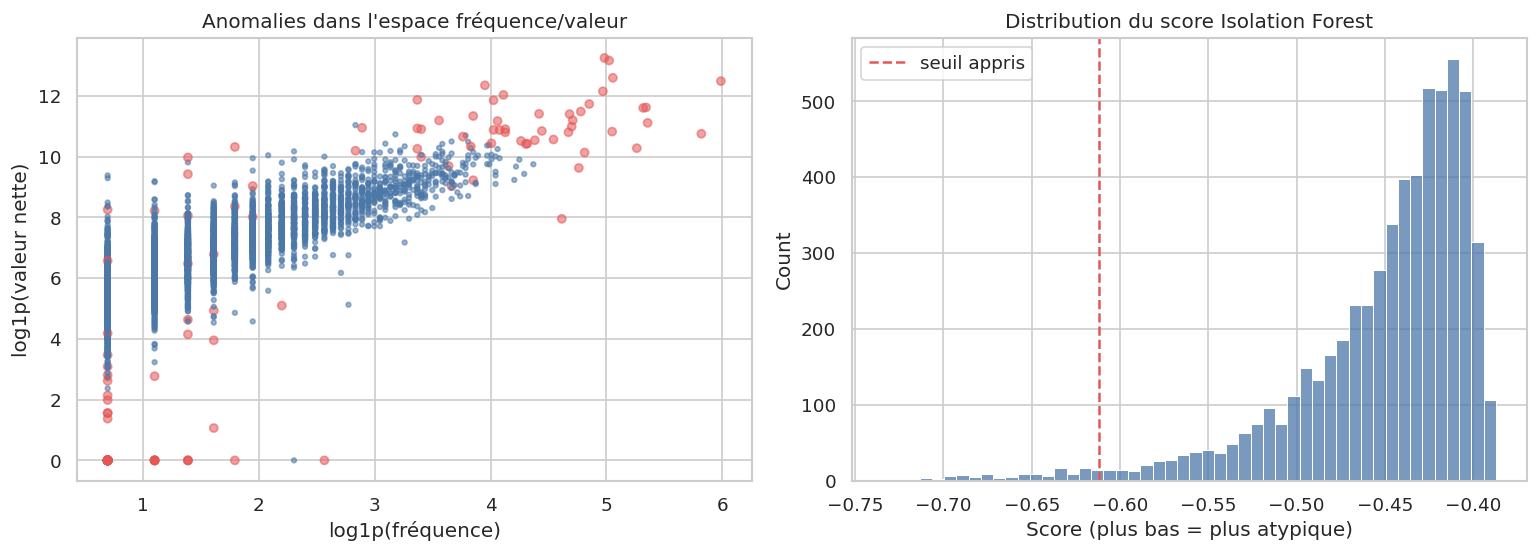

In [6]:
# Isolation Forest sur les mêmes variables préparées que le clustering.
isolation_forest = IsolationForest(
    n_estimators=300,
    contamination=0.02,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
anomaly_label = isolation_forest.fit_predict(X_model)
anomaly_score = isolation_forest.score_samples(X_model)  # plus bas = plus atypique
customer["anomaly_score"] = anomaly_score
customer["is_anomaly"] = anomaly_label == -1

q99 = customer[FEATURES].quantile(0.99)

def investigate_client(row):
    reasons = []
    if row["return_rate_lines"] > max(0.50, q99["return_rate_lines"]):
        reasons.append("retours très élevés")
    if row["quantity_total"] > q99["quantity_total"] and row["unique_products"] > customer["unique_products"].median():
        reasons.append("grossiste probable")
    if row["monetary_net"] > q99["monetary_net"]:
        reasons.append("client exceptionnel à forte valeur")
    if row["avg_basket"] > q99["avg_basket"]:
        reasons.append("panier exceptionnel")
    if row["recency_days"] > q99["recency_days"] and row["frequency"] <= 2:
        reasons.append("ancien client très inactif")
    if row["monetary_net"] < 0:
        reasons.append("valeur nette négative à contrôler")
    return ", ".join(reasons) if reasons else "combinaison multivariée atypique à investiguer"

anomalies = customer[customer["is_anomaly"]].copy().sort_values("anomaly_score")
anomalies["diagnostic_métier"] = anomalies.apply(investigate_client, axis=1)

top_anomalies = anomalies.head(15)[
    ["main_country", "segment", "recency_days", "frequency", "monetary_net",
     "avg_basket", "quantity_total", "unique_products", "return_rate_lines",
     "anomaly_score", "diagnostic_métier"]
]

print(f"Isolation Forest signale {len(anomalies)} clients ({100*len(anomalies)/len(customer):.2f}%).")
print("Analyse individuelle des 15 scores les plus extrêmes :")
display(top_anomalies.round(3))

diagnostic_counts = (
    anomalies["diagnostic_métier"].value_counts().rename_axis("diagnostic").to_frame("clients")
)
display(diagnostic_counts.head(12))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].scatter(
    np.log1p(customer["frequency"]),
    np.log1p(customer["monetary_net"].clip(lower=0)),
    c=np.where(customer["is_anomaly"], "#E45756", "#4C78A8"),
    s=np.where(customer["is_anomaly"], 24, 8), alpha=0.55,
)
axes[0].set(title="Anomalies dans l'espace fréquence/valeur", xlabel="log1p(fréquence)", ylabel="log1p(valeur nette)")
sns.histplot(customer["anomaly_score"], bins=50, ax=axes[1], color="#4C78A8")
axes[1].axvline(anomalies["anomaly_score"].max(), color="#E45756", linestyle="--", label="seuil appris")
axes[1].set(title="Distribution du score Isolation Forest", xlabel="Score (plus bas = plus atypique)")
axes[1].legend()
plt.tight_layout()

print("Décision : aucun client n'est supprimé automatiquement. Les gros volumes peuvent correspondre à des grossistes ou clients exceptionnels ; les retours extrêmes et valeurs nettes négatives demandent un contrôle des factures sources.")

## Executive segmentation memo — 5 pts

Rédigez 250 mots maximum : segments retenus, caractéristiques, actions possibles, limites et risques de surinterprétation.

In [7]:
# Mémo généré uniquement à partir des résultats de cette exécution (moins de 250 mots).
segment_sentences = []
for cluster_id, row in profile_named.sort_values("part_%", ascending=False).iterrows():
    order_word = "commande" if round(row["frequency"]) == 1 else "commandes"
    segment_sentences.append(
        f"{row['segment']} ({row['part_%']:.1f}%): récence médiane {row['recency_days']:.0f} j, "
        f"{row['frequency']:.0f} {order_word} et valeur nette médiane £{row['monetary_net']:.0f}."
    )

memo = (
    f"La segmentation retient {SELECTED_K} groupes K-Means après comparaison de K=2 à 10 par inertie, silhouette, "
    f"Calinski-Harabasz, Davies-Bouldin et taille minimale. "
    + " ".join(segment_sentences)
    + f" Actions proposées : service prioritaire pour les clients de forte valeur ; réactivation ciblée des inactifs ; "
      f"récompenses de fidélité pour les clients réguliers ; contrôle séparé des retours. "
      f"La CAH présente un accord ARI de {ari_kmeans_cah:.2f} avec K-Means sur l'échantillon. DBSCAN, avec eps={BEST_EPS:.2f}, "
      f"isole {dbscan_noise_pct:.1f}% de bruit et révèle une structure de densité différente. "
      f"PCA nécessite {n80} composantes pour expliquer 80% de la variance ; les cartes t-SNE changent selon la perplexité et ne prouvent pas l'existence des segments. "
      f"Isolation Forest signale {len(anomalies)} clients à examiner, sans suppression automatique. "
      f"Limites : données anciennes, achats sans identifiant exclus, seuils et nombre de groupes sensibles au preprocessing, absence de vérité terrain. "
      f"Avant usage opérationnel, il faut tester la stabilité temporelle, relier les segments aux campagnes et vérifier les factures atypiques."
)

word_count = len(memo.split())
print("EXECUTIVE SEGMENTATION MEMO")
print(memo)
print(f"\nNombre de mots : {word_count} (maximum demandé : 250)")
if word_count > 250:
    raise ValueError("Le mémo dépasse 250 mots")

print("\nREPRODUCTIBILITÉ")
print(f"random_state={RANDOM_STATE}; clients={len(customer)}; features={len(FEATURES)}; K={SELECTED_K}; eps={BEST_EPS:.4f}; min_samples={MIN_SAMPLES}")
print(f"pandas={pd.__version__}; numpy={np.__version__}; scikit-learn importé depuis l'environnement Python {platform.python_version()}")

EXECUTIVE SEGMENTATION MEMO
La segmentation retient 3 groupes K-Means après comparaison de K=2 à 10 par inertie, silhouette, Calinski-Harabasz, Davies-Bouldin et taille minimale. Fidèles (39.2%): récence médiane 97 j, 4 commandes et valeur nette médiane £962. Inactifs (36.0%): récence médiane 382 j, 1 commande et valeur nette médiane £255. Forte valeur (24.9%): récence médiane 19 j, 11 commandes et valeur nette médiane £4303. Actions proposées : service prioritaire pour les clients de forte valeur ; réactivation ciblée des inactifs ; récompenses de fidélité pour les clients réguliers ; contrôle séparé des retours. La CAH présente un accord ARI de 0.56 avec K-Means sur l'échantillon. DBSCAN, avec eps=1.05, isole 13.2% de bruit et révèle une structure de densité différente. PCA nécessite 4 composantes pour expliquer 80% de la variance ; les cartes t-SNE changent selon la perplexité et ne prouvent pas l'existence des segments. Isolation Forest signale 118 clients à examiner, sans suppress

## Reproductibilité — 5 pts

### Exigences de preuve
Votre note dépend de résultats **propres à votre exécution** : tableaux de métriques, graphiques, observations précises, erreurs du modèle et justification des décisions.  
Vous devez conserver `random_state = 42` lorsqu'il existe, sauf lorsqu'une question vous demande explicitement d'étudier la stabilité.

### Ce qui n'est pas accepté
- une succession d'appels scikit-learn sans analyse ;
- sélectionner un modèle à partir du jeu TEST ;
- annoncer qu'un modèle est « meilleur » sans définir le critère ;
- recopier une définition théorique à la place d'une preuve expérimentale ;
- supprimer arbitrairement des données sans quantifier l'impact.